# Detecção de Anomalias em Licitações Públicas de TI
## Pipeline Completo: Pré-processamento → Mineração → Interpretação

---

Este notebook é **autocontido**: executa todas as etapas do processo KDD (Fayyad et al., 1996)
em sequência, desde o carregamento dos arquivos CSV brutos até a exportação dos resultados.

### Etapas implementadas

| Etapa KDD | Seção | O que faz |
|---|---|---|
| Seleção | 1 | Carrega os CSVs dos anos 2020–2025 |
| Pré-processamento | 2 | Limpeza, tipos corretos, tratamento de ausentes |
| Transformação | 3 | Features derivadas (sobrepreço, lead time, flags) |
| Mineração | 4–7 | Isolation Forest + LOF (detecção não-supervisionada) |
| Interpretação | 8 | Score ensemble, perfil das anomalias, gráficos |

### Por que detecção não-supervisionada?

O dataset **não possui rótulos** — não há registros previamente classificados como
fraudulentos ou regulares. Nesse cenário, Chandola, Banerjee e Kumar (2009) indicam
algoritmos que detectam desvios estatísticos sem depender de exemplos rotulados.

A abordagem adotada combina dois algoritmos complementares:

- **Isolation Forest** (Liu, Ting & Zhou, 2008): isola instâncias usando árvores aleatórias.
  Anomalias são raras e diferentes — portanto são isoladas com menos cortes.
  Treinado no dataset **completo** (todos os anos, todas as modalidades) para que o modelo
  aprenda o que é "normal" no universo inteiro de licitações do estado.

- **LOF — Local Outlier Factor** (Breunig et al., 2000): compara a densidade local de cada
  registro com a de seus vizinhos mais próximos. Detecta anomalias **locais** (incomuns
  dentro do próprio contexto de TI), complementando o IF que detecta anomalias **globais**.

### Referências principais

- Fayyad, Piatetsky-Shapiro e Smyth (1996): processo KDD
- Liu, Ting e Zhou (2008): Isolation Forest — IEEE ICDM
- Breunig et al. (2000): LOF — ACM SIGMOD
- Chandola, Banerjee e Kumar (2009): Anomaly Detection Survey — ACM CSUR
- Lundberg e Lee (2017): SHAP — NeurIPS
- Lei 14.133/2021: Nova Lei de Licitações e Contratos Administrativos

---
## 1 — Importações e Configurações Globais

In [2]:
# =============================================================================
# IMPORTAÇÕES
# =============================================================================
# Suprimimos avisos irrelevantes para não poluir a saída do notebook.
import warnings
warnings.filterwarnings('ignore')

# Manipulação de dados
import pandas as pd
import numpy as np
from pathlib import Path                          # manipulação de caminhos multiplataforma
from IPython.display import display, FileLink     # exibe tabelas e links no notebook

# Pré-processamento para o modelo de ML
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Algoritmos de detecção de anomalias
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# SHAP: explica individualmente por que cada registro foi considerado anômalo.
# É opcional — o notebook funciona sem ele, mas com interpretabilidade reduzida.
# Para instalar: pip install shap
try:
    import shap
    SHAP_DISPONIVEL = True
    print('✓ SHAP disponível — interpretabilidade por instância ativada')
except ImportError:
    SHAP_DISPONIVEL = False
    print('⚠ SHAP não encontrado (pip install shap para ativar)')
    print('  Será usada análise de desvio por feature como alternativa.')

# =============================================================================
# CONFIGURAÇÕES GLOBAIS
# =============================================================================
pd.options.display.max_columns  = 50
pd.options.display.max_colwidth = 120
pd.options.display.float_format = lambda x: f'{x:,.2f}'

# Pasta onde os resultados serão salvos
EXPORTS_DIR = Path('exports')
EXPORTS_DIR.mkdir(exist_ok=True)

# Semente aleatória — garante que os resultados sejam reproduzíveis
RANDOM_STATE = 42

print('\nConfiguração concluída.')

✓ SHAP disponível — interpretabilidade por instância ativada

Configuração concluída.


---
## 2 — Seleção dos Dados

Carregamos todos os arquivos CSV disponíveis (um por ano) e os concatenamos em um único
DataFrame. Cada arquivo segue o mesmo layout do portal de licitações do Estado do Paraná:
separador `;`, cabeçalho na primeira linha, valores monetários com vírgula decimal.

Todos os campos são lidos como `str` (string) nesta etapa para evitar conversões automáticas
incorretas — a tipagem correta é feita na etapa seguinte.

In [3]:
# =============================================================================
# CAMINHOS DOS ARQUIVOS
# Adicione ou remova anos conforme a disponibilidade dos dados.
# =============================================================================
csv_paths = [
    Path('./data/TB_LICITACOES-2025.csv'),
    Path('./data/TB_LICITACOES-2024.csv'),
    Path('./data/TB_LICITACOES-2023.csv'),
    Path('./data/TB_LICITACOES-2022.csv'),
    Path('./data/TB_LICITACOES-2021.csv'),
    Path('./data/TB_LICITACOES-2020.csv'),
]

frames = []
for path_csv in csv_paths:
    if not path_csv.exists():
        print(f'  ⚠ Arquivo não encontrado: {path_csv} — ignorado')
        continue

    frame = (
        pd.read_csv(path_csv, sep=';', dtype=str)  # lê tudo como texto para evitar erros
            .rename(columns=str.lower)              # padroniza nomes de colunas em minúsculas
            .assign(arquivo=path_csv.name)          # registra de qual arquivo veio cada linha
    )
    frames.append(frame)
    print(f'  ✓ {path_csv.name}: {len(frame):,} registros')

# Concatena todos os anos em um único DataFrame
raw_df = pd.concat(frames, ignore_index=True)

print(f'\nTotal carregado: {len(raw_df):,} registros  |  {raw_df.shape[1]} colunas')
raw_df.head(3)

  ✓ TB_LICITACOES-2025.csv: 1,732 registros
  ✓ TB_LICITACOES-2024.csv: 2,645 registros
  ✓ TB_LICITACOES-2023.csv: 2,725 registros
  ✓ TB_LICITACOES-2022.csv: 2,708 registros
  ✓ TB_LICITACOES-2021.csv: 2,028 registros
  ✓ TB_LICITACOES-2020.csv: 1,698 registros

Total carregado: 13,536 registros  |  19 colunas


,numprocesso,ano,modalidade,situacao,objeto,orgao,registrodepreco,vigenciaata,revogacaoata,criteriojulgamento,valor_estimado,valor_ou_desconto_homologado,dataabertura,datahomologacao,localdisputa,idlicitacoes,protocolo,tempoprazocontrato,arquivo
0,1,2025,Audiência Pública,Fase Certame,Audiência Pública visa consultar os eventuais interessados no Credenciamento de Entidades Médicas e Psicológicas de ...,DETRAN-Departamento de Trânsito do Estado do Paraná,Não,NaN,NaN,-,0.00,NaN,2025-02-19,NaN,NaN,NaN,234022687,NaN,TB_LICITACOES-2025.csv
1,2,2025,Audiência Pública,Adjudicado,AUDIÊNCIA PÚBLICA DO PROGRAMA GANHANDO O MUNDO.,SEED-Secretaria de Estado da Educação,Não,NaN,NaN,Menor Preço,0.00,NaN,2025-05-22,NaN,NaN,NaN,239262546,1 Parcela(s) - Empreitada/Global,TB_LICITACOES-2025.csv
2,3,2025,Audiência Pública,Fase Certame,Audiência Pública que visa obter contribuições para compor o Estudo Técnico Preliminar e Termo de Referência para po...,SEAP-Secretaria de Estado da Administração e da Previdência,Não,NaN,NaN,Menor Preço,0.00,NaN,2025-06-04,NaN,NaN,NaN,239013830,NaN,TB_LICITACOES-2025.csv


---
## 3 — Pré-processamento

Esta etapa transforma os dados brutos em um formato utilizável:

1. **Remoção de colunas irrelevantes** para o escopo desta análise
2. **Conversão de datas** de string para `datetime`
3. **Conversão de valores monetários** de string (formato brasileiro) para `float`
4. **Normalização do texto** descritivo (`objeto`) para facilitar busca por palavras-chave

In [4]:
# =============================================================================
# FUNÇÃO AUXILIAR: conversão de data com tolerância a erros
# =============================================================================
def para_datetime(series, fmt='%Y-%m-%d'):
    """
    Converte uma Series de strings para datetime.
    Strings inválidas ou ausentes viram NaT (Not a Time) em vez de gerar erro.
    """
    return pd.to_datetime(series, format=fmt, errors='coerce')


# =============================================================================
# CÓPIA DO RAW — nunca modificamos o original para poder reprocessar se necessário
# =============================================================================
clean_df = raw_df.copy()

# =============================================================================
# 3.1 — REMOÇÃO DE COLUNAS DESNECESSÁRIAS
# Colunas removidas e motivo:
#   registrodepreco  → informação binária já codificada nas flags de desconto
#   vigenciaata      → relevante apenas para contratos, fora do escopo
#   revogacaoata     → idem
#   localdisputa     → não influencia detecção de anomalias financeiras
#   idlicitacoes     → identificador interno sem valor analítico
#   protocolo        → idem
#   tempoprazocontrato → dado textual não estruturado de difícil padronização
# =============================================================================
colunas_remover = [
    'registrodepreco', 'vigenciaata', 'revogacaoata',
    'localdisputa', 'idlicitacoes', 'protocolo', 'tempoprazocontrato'
]
clean_df = clean_df.drop(columns=colunas_remover, errors='ignore')

# =============================================================================
# 3.2 — CONVERSÃO DE DATAS
# dataabertura:    data em que o certame foi aberto ao público
# datahomologacao: data em que o resultado foi oficialmente homologado
# =============================================================================
clean_df['dataabertura']    = para_datetime(clean_df['dataabertura'])
clean_df['datahomologacao'] = para_datetime(clean_df['datahomologacao'])

# =============================================================================
# 3.3 — CONVERSÃO DE VALORES MONETÁRIOS
# Os CSVs usam formato brasileiro: ponto como separador de milhar, vírgula como decimal.
# Exemplo: "1.234.567,89" → 1234567.89
# Passo 1: remove os pontos de milhar
# Passo 2: troca a vírgula decimal por ponto
# Passo 3: converte para float (erros viram NaN)
# =============================================================================
for col in ['valor_estimado', 'valor_ou_desconto_homologado']:
    clean_df[col] = (
        clean_df[col]
        .str.replace('.', '', regex=False)   # remove separador de milhar
        .str.replace(',', '.', regex=False)  # troca decimal
    )
    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

# =============================================================================
# 3.4 — NORMALIZAÇÃO DO TEXTO DO OBJETO
# Transforma tudo em minúsculas, remove espaços extras e colapsa múltiplos
# espaços em um único. Isso garante que buscas por palavras-chave funcionem
# independentemente de maiúsculas/minúsculas ou formatação original.
# =============================================================================
clean_df['objeto_normalizado'] = (
    clean_df['objeto']
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)  # colapsa múltiplos espaços em um
)

print(f'Registros após pré-processamento: {len(clean_df):,}')
print(f'Datas válidas (abertura):    {clean_df["dataabertura"].notna().sum():,}')
print(f'Datas válidas (homologação): {clean_df["datahomologacao"].notna().sum():,}')
print(f'Com valor_estimado > 0:      {(clean_df["valor_estimado"] > 0).sum():,}')
clean_df.head(3)

Registros após pré-processamento: 13,536
Datas válidas (abertura):    13,523
Datas válidas (homologação): 10,755
Com valor_estimado > 0:      13,119


,numprocesso,ano,modalidade,situacao,objeto,orgao,criteriojulgamento,valor_estimado,valor_ou_desconto_homologado,dataabertura,datahomologacao,arquivo,objeto_normalizado
0,1,2025,Audiência Pública,Fase Certame,Audiência Pública visa consultar os eventuais interessados no Credenciamento de Entidades Médicas e Psicológicas de ...,DETRAN-Departamento de Trânsito do Estado do Paraná,-,0.00,NaN,2025-02-19,NaT,TB_LICITACOES-2025.csv,audiência pública visa consultar os eventuais interessados no credenciamento de entidades médicas e psicológicas de ...
1,2,2025,Audiência Pública,Adjudicado,AUDIÊNCIA PÚBLICA DO PROGRAMA GANHANDO O MUNDO.,SEED-Secretaria de Estado da Educação,Menor Preço,0.00,NaN,2025-05-22,NaT,TB_LICITACOES-2025.csv,audiência pública do programa ganhando o mundo.
2,3,2025,Audiência Pública,Fase Certame,Audiência Pública que visa obter contribuições para compor o Estudo Técnico Preliminar e Termo de Referência para po...,SEAP-Secretaria de Estado da Administração e da Previdência,Menor Preço,0.00,NaN,2025-06-04,NaT,TB_LICITACOES-2025.csv,audiência pública que visa obter contribuições para compor o estudo técnico preliminar e termo de referência para po...


---
## 4 — Transformação: Features Derivadas

Criamos variáveis que não existem diretamente nos dados mas são fundamentais para
identificar padrões anômalos:

| Variável | Fórmula | Significado |
|---|---|---|
| `diferenca_valor` | estimado − homologado | Positivo = economia; negativo = sobrepreço |
| `variacao_percentual` | diferença / estimado × 100 | Desvio relativo normalizado por porte |
| `proporcao_homologado_estimado` | homologado / estimado | Base para detectar sobrepreço (> 1) |
| `lead_time_dias` | (datahomologacao − dataabertura).days | Duração total do processo |
| `criterio_menor_preco` | contém "Menor Preço" no critério | Ligado ao Art. 34, Lei 14.133/2021 |
| `flag_situacao_certame` | situacao contém "Fase Certame" | Processo ainda em andamento |

In [5]:
# =============================================================================
# CONDIÇÃO: só calculamos relações entre valores quando AMBOS estão presentes
# e o estimado é diferente de zero (para evitar divisão por zero).
# =============================================================================
cond_valores = (
    clean_df['valor_estimado'].notna()
    & clean_df['valor_estimado'].ne(0)
    & clean_df['valor_ou_desconto_homologado'].notna()
)

# =============================================================================
# DIFERENÇA DE VALOR
# Calculada como (estimado - homologado) para que valores positivos indiquem
# economia (homologado abaixo do estimado) e valores negativos indiquem sobrepreço.
# Quando um dos valores está ausente, preenchemos com 0 para não propagar NaN.
# =============================================================================
clean_df['diferenca_valor'] = np.where(
    clean_df['valor_estimado'].notna() & clean_df['valor_ou_desconto_homologado'].notna(),
    clean_df['valor_estimado'] - clean_df['valor_ou_desconto_homologado'],
    0.0
)

# =============================================================================
# VARIAÇÃO PERCENTUAL
# Normaliza a diferença pelo valor estimado — essencial para comparar licitações
# de portes muito diferentes (R$10k vs R$10M teriam diferenças absolutas incomparáveis).
# =============================================================================
clean_df['variacao_percentual'] = np.where(
    cond_valores,
    (clean_df['diferenca_valor'] / clean_df['valor_estimado']) * 100,
    0.0
)

# =============================================================================
# PROPORÇÃO HOMOLOGADO/ESTIMADO
# Valores > 1 indicam que o valor final superou a estimativa (possível sobrepreço).
# Valores < 1 indicam desconto obtido no certame.
# =============================================================================
clean_df['proporcao_homologado_estimado'] = np.where(
    cond_valores,
    clean_df['valor_ou_desconto_homologado'] / clean_df['valor_estimado'],
    0.0
)

# =============================================================================
# FLAGS BINÁRIAS FINANCEIRAS
# flag_homologado_acima_estimado: True quando o valor final excedeu a estimativa
# flag_houve_desconto: True quando houve redução de preço no certame
# =============================================================================
clean_df['flag_homologado_acima_estimado'] = clean_df['proporcao_homologado_estimado'] > 1
clean_df['flag_houve_desconto'] = clean_df['proporcao_homologado_estimado'].between(
    0, 1, inclusive='left'
)

# =============================================================================
# LEAD TIME (PRAZO DO PROCESSO)
# Mede em dias o tempo entre a abertura pública e a homologação.
# Prazos negativos (erros de data) são zerados; ausentes (processo não finalizado)
# também são preenchidos com 0 para não interferir no modelo.
# =============================================================================
clean_df['lead_time_dias'] = (
    (clean_df['datahomologacao'] - clean_df['dataabertura']).dt.days
    .clip(lower=0)   # remove prazos negativos (inconsistências de data)
    .fillna(0)       # processos não finalizados recebem 0
)

# =============================================================================
# FLAGS CATEGÓRICAS
# criterio_menor_preco: Art. 34, Lei 14.133/2021 — critério mais comum e competitivo
# flag_situacao_certame: processos ainda em aberto têm dados incompletos
# =============================================================================
clean_df['criterio_menor_preco'] = clean_df['criteriojulgamento'].str.contains(
    'Menor Preço', case=False, na=False
)
clean_df['flag_situacao_certame'] = clean_df['situacao'].str.contains(
    'Fase Certame', case=False, na=False
)

print(f'Features derivadas criadas com sucesso.')
print(f'Registros com sobrepreço (homologado > estimado): '
      f'{clean_df["flag_homologado_acima_estimado"].sum():,}')
print(f'Registros com desconto obtido:                    '
      f'{clean_df["flag_houve_desconto"].sum():,}')
print(f'Lead time médio (processos finalizados):          '
      f'{clean_df[clean_df["lead_time_dias"] > 0]["lead_time_dias"].mean():.0f} dias')
clean_df.head(3)

Features derivadas criadas com sucesso.
Registros com sobrepreço (homologado > estimado): 116
Registros com desconto obtido:                    13,059
Lead time médio (processos finalizados):          45 dias


,numprocesso,ano,modalidade,situacao,objeto,orgao,criteriojulgamento,valor_estimado,valor_ou_desconto_homologado,dataabertura,datahomologacao,arquivo,objeto_normalizado,diferenca_valor,variacao_percentual,proporcao_homologado_estimado,flag_homologado_acima_estimado,flag_houve_desconto,lead_time_dias,criterio_menor_preco,flag_situacao_certame
0,1,2025,Audiência Pública,Fase Certame,Audiência Pública visa consultar os eventuais interessados no Credenciamento de Entidades Médicas e Psicológicas de ...,DETRAN-Departamento de Trânsito do Estado do Paraná,-,0.00,NaN,2025-02-19,NaT,TB_LICITACOES-2025.csv,audiência pública visa consultar os eventuais interessados no credenciamento de entidades médicas e psicológicas de ...,0.00,0.00,0.00,False,True,0.00,False,True
1,2,2025,Audiência Pública,Adjudicado,AUDIÊNCIA PÚBLICA DO PROGRAMA GANHANDO O MUNDO.,SEED-Secretaria de Estado da Educação,Menor Preço,0.00,NaN,2025-05-22,NaT,TB_LICITACOES-2025.csv,audiência pública do programa ganhando o mundo.,0.00,0.00,0.00,False,True,0.00,True,False
2,3,2025,Audiência Pública,Fase Certame,Audiência Pública que visa obter contribuições para compor o Estudo Técnico Preliminar e Termo de Referência para po...,SEAP-Secretaria de Estado da Administração e da Previdência,Menor Preço,0.00,NaN,2025-06-04,NaT,TB_LICITACOES-2025.csv,audiência pública que visa obter contribuições para compor o estudo técnico preliminar e termo de referência para po...,0.00,0.00,0.00,False,True,0.00,True,True


---
## 5 — Filtro de Licitações de Tecnologia da Informação

Delimitamos o escopo do TCC ao nicho de TI filtrando registros cujo objeto contenha
termos relacionados a software, hardware ou serviços de tecnologia.

### Refinamento em relação a versões anteriores

O filtro anterior incluía o termo `sistema` de forma isolada, o que capturava falsos
positivos como *"sistema de drenagem"*, *"sistema rodoviário"* e *"sistema de contenção"*.
O filtro atual exige contexto tecnológico: usa `sistema de informação`, `sistema integrado`,
`sistema computacional`, etc.

In [6]:
# =============================================================================
# LISTA DE PALAVRAS-CHAVE DE TI
# Organizadas por categoria para facilitar manutenção e extensão futura.
# Todas em minúsculas para bater com o objeto_normalizado.
# =============================================================================
KEYWORDS_TI = [
    # --- Software e plataformas ---
    'software', 'aplicativo', 'plataforma digital', 'solução tecnológica',
    'sistema de informação', 'sistema informatizado', 'sistema computacional',
    'sistema integrado', 'erp', 'crm', 'saas', 'paas', 'cloud',

    # --- Hardware e equipamentos ---
    'computador', 'notebook', 'servidor', 'workstation', 'periférico',
    'roteador', 'switch', 'firewall', 'datacenter', 'data center',
    'impressora', 'scanner', 'nobreak', 'rack', 'storage',

    # --- Serviços de TI ---
    'suporte técnico', 'manutenção de ti', 'serviços de ti',
    'tecnologia da informação', 'outsourcing de impressão',
    'helpdesk', 'help desk', 'servicedesk', 'service desk',
    'segurança da informação', 'cibersegurança', 'backup',
    'monitoramento de rede', 'infraestrutura de rede',
    'videomonitoramento', 'cftv', 'câmera de segurança',
    'integração de dados', 'business intelligence', 'analytics',

    # --- Licenças ---
    'licença de software', 'licença microsoft', 'licença oracle',
    'licença adobe', 'assinatura de software',

    # --- Telecomunicações e conectividade ---
    'link de internet', 'fibra óptica', 'telecomunicação',
    'conectividade', 'banda larga',
]

# Cria a máscara: True se qualquer keyword estiver presente no objeto_normalizado
texto = clean_df['objeto_normalizado'].fillna('')
mask_ti = texto.apply(lambda t: any(kw in t for kw in KEYWORDS_TI))

# Marca a coluna no dataset completo (útil para referência cruzada)
clean_df['flag_informatica'] = mask_ti

# Cria o subconjunto de TI que será o foco da análise
df_ti = clean_df[mask_ti].copy()

print(f'Total de registros:                  {len(clean_df):,}')
print(f'Registros de TI (filtro refinado):   {len(df_ti):,} '
      f'({len(df_ti)/len(clean_df)*100:.1f}%)')
print(f'\nModalidades mais frequentes em TI:')
print(df_ti['modalidade'].value_counts().head(8).to_string())

# Mostra a distribuição de situações para entender o grau de completude dos dados
print(f'\nSituações dos processos de TI:')
print(df_ti['situacao'].value_counts().head(10).to_string())

Total de registros:                  13,536
Registros de TI (filtro refinado):   748 (5.5%)

Modalidades mais frequentes em TI:
modalidade
Pregão Eletrônico                              447
Pregão Eletrônico (Lei Federal 14.133/2021)    223
Licitação Eletrônica - Estatal                  42
Chamamento Público                              10
Audiência Pública                                5
Concorrência Pública                             5
Credenciamento                                   4
Licitação Presencial - Estatal                   3

Situações dos processos de TI:
situacao
Homologado                 587
Fase Certame                62
Fracassado                  27
Suspenso                    15
Cancelado                   11
Publicado                    9
Anulado                      8
Homologado Parcialmente      8
Deserto                      8
Revogado                     8


### Análise de Completude Financeira

Antes de aplicar os algoritmos, é importante entender quantos registros possuem
dados financeiros completos, pois isso determina quais features estarão disponíveis.

In [7]:
# Verifica a completude dos dados financeiros no subconjunto TI
tem_estimado   = df_ti['valor_estimado'].notna() & (df_ti['valor_estimado'] > 0)
tem_homologado = df_ti['valor_ou_desconto_homologado'].notna() & (df_ti['valor_ou_desconto_homologado'] > 0)
tem_ambos      = tem_estimado & tem_homologado

print('=== Completude dos Dados Financeiros — Subconjunto TI ===')
print(f'  Com valor_estimado > 0:              {tem_estimado.sum():>5,} ({tem_estimado.mean()*100:.1f}%)')
print(f'  Com valor_homologado > 0:            {tem_homologado.sum():>5,} ({tem_homologado.mean()*100:.1f}%)')
print(f'  Com AMBOS os valores preenchidos:    {tem_ambos.sum():>5,} ({tem_ambos.mean()*100:.1f}%)')
print(f'  Apenas dados temporais/categóricos:  {(~tem_ambos).sum():>5,} ({(~tem_ambos).mean()*100:.1f}%)')
print()
print('Nota: registros sem dados financeiros entram no modelo,')
print('mas contribuem apenas com features temporais e categóricas.')
print('Anomalias financeiras (sobrepreço) só são detectáveis nos registros com ambos os valores.')

=== Completude dos Dados Financeiros — Subconjunto TI ===
  Com valor_estimado > 0:                699 (93.4%)
  Com valor_homologado > 0:              490 (65.5%)
  Com AMBOS os valores preenchidos:      490 (65.5%)
  Apenas dados temporais/categóricos:    258 (34.5%)

Nota: registros sem dados financeiros entram no modelo,
mas contribuem apenas com features temporais e categóricas.
Anomalias financeiras (sobrepreço) só são detectáveis nos registros com ambos os valores.


---
## 6 — Engenharia de Features para Detecção de Anomalias

Construímos a matriz de features que alimentará os algoritmos de ML.
Cada feature foi escolhida por relevância no domínio de licitações públicas
e por adequação matemática aos algoritmos usados.

### Por que transformação logarítmica nos valores monetários?

Os valores de licitações variam de centenas a centenas de milhões de reais.
Sem transformação, o Isolation Forest seria dominado pelas licitações de alto valor,
ignorando padrões em licitações menores. A transformação `log1p(x) = log(1 + x)`
comprime essa escala mantendo a ordenação e tratando o caso `x = 0` corretamente.

### Estratégia para dados ausentes

Registros sem valores financeiros recebem 0 nas features financeiras — o que é
semanticamente correto: esses processos de fato não têm variação conhecida.
O campo `tem_dados_financeiros` explicita isso para o modelo.

In [8]:
# =============================================================================
# FUNÇÃO AUXILIAR: agrupa modalidades em categorias de alto nível
# Reduz a fragmentação (dezenas de modalidades → 7 grupos) para que o
# LabelEncoder produza uma escala ordinal com densidade suficiente.
# =============================================================================
def agrupar_modalidade(modalidade):
    if pd.isna(modalidade):
        return 'Outros'
    m = str(modalidade).lower()
    if 'pregão' in m:          return 'Pregão'
    if 'concorrência' in m:    return 'Concorrência'
    if 'dispensa' in m:        return 'Dispensa'
    if 'inexigibilidade' in m: return 'Inexigibilidade'
    if 'credenciamento' in m or 'chamamento' in m: return 'Credenciamento'
    if 'audiência' in m:       return 'Audiência Pública'
    return 'Outros'


# =============================================================================
# FUNÇÃO PRINCIPAL: constrói a matriz de features a partir de qualquer DataFrame
# com o mesmo layout do dataset de licitações.
# Recebe: DataFrame com colunas do dataset limpo
# Retorna: DataFrame com apenas as features numéricas para o modelo
# =============================================================================
def construir_features(df, le_modalidade=None, freq_orgao_ref=None):
    """
    Parâmetros
    ----------
    df              : DataFrame de entrada (dataset limpo)
    le_modalidade   : LabelEncoder já ajustado; se None, cria e ajusta novo
    freq_orgao_ref  : Series com frequências de referência dos órgãos;
                      se None, calcula a partir do próprio df

    Retorna
    -------
    feat            : DataFrame de features numéricas
    le_modalidade   : LabelEncoder ajustado (para reutilização)
    freq_orgao_ref  : Series de frequências (para reutilização)
    """
    feat = pd.DataFrame(index=df.index)

    # ------------------------------------------------------------------
    # Features financeiras
    # ------------------------------------------------------------------
    v_est = df['valor_estimado'].fillna(0).clip(lower=0)
    v_hom = df['valor_ou_desconto_homologado'].fillna(0).clip(lower=0)
    tem   = (v_est > 0) & (v_hom > 0)  # máscara de dados financeiros presentes

    # Log do valor estimado: comprime a escala monetária (de centenas a bilhões)
    feat['valor_estimado_log1p'] = np.log1p(v_est)

    # Proporção homologado/estimado:
    #   < 1 → desconto obtido (bom sinal de competitividade)
    #   > 1 → sobrepreço (sinal de alerta)
    #   = 0 → sem dados financeiros
    # Limitamos em 5× para que valores extremos não distorçam o scaler
    proporcao = np.where(v_est > 0, v_hom / v_est, 0.0)
    feat['proporcao_homologado_estimado'] = np.clip(proporcao, 0, 5)

    # Sobrepreço em percentual (só valores positivos — acima da estimativa)
    # max(0, ...) captura apenas os casos em que o final excedeu o estimado
    sob = np.where(tem, np.maximum(0, v_hom - v_est) / v_est * 100, 0.0)
    feat['sobrepreco_percentual'] = np.clip(sob, 0, 500)  # cap: 500% de sobrepreço máximo

    # Desconto em percentual (só valores positivos — abaixo da estimativa)
    desc = np.where(tem, np.maximum(0, v_est - v_hom) / v_est * 100, 0.0)
    feat['desconto_percentual'] = np.clip(desc, 0, 100)   # cap: 100% de desconto máximo

    # Feature binária indicando se o registro tem dados financeiros completos
    # O modelo usa isso para distinguir "proporção 0 por ausência" de "proporção 0 real"
    feat['tem_dados_financeiros'] = tem.astype(int)

    # ------------------------------------------------------------------
    # Features temporais
    # ------------------------------------------------------------------
    lead = df.get('lead_time_dias', pd.Series(0, index=df.index)).fillna(0).clip(lower=0)
    # Log do lead time: prazos variam de 1 a 600+ dias; log1p normaliza a escala
    feat['lead_time_log1p'] = np.log1p(lead)

    data_ab = pd.to_datetime(df['dataabertura'], errors='coerce')
    # Mês de abertura: captura sazonalidade (ex.: concentração de processos em dezembro)
    feat['mes_abertura'] = data_ab.dt.month.fillna(6).astype(int)
    # Ano: permite ao modelo capturar tendências temporais
    feat['ano'] = data_ab.dt.year.fillna(2022).astype(int)

    # ------------------------------------------------------------------
    # Features categóricas
    # ------------------------------------------------------------------
    # Critério de julgamento: Menor Preço (True=1) é o critério mais competitivo;
    # outros critérios (Técnica e Preço, Maior Desconto etc.) são menos comuns
    feat['criterio_menor_preco'] = df.get(
        'criterio_menor_preco',
        df['criteriojulgamento'].str.contains('Menor Preço', case=False, na=False)
    ).astype(int)

    # Modalidade agrupada: codificada numericamente para o modelo
    grupo_modal = df['modalidade'].apply(agrupar_modalidade)
    if le_modalidade is None:
        le_modalidade = LabelEncoder()
        feat['modalidade_grupo'] = le_modalidade.fit_transform(grupo_modal)
    else:
        # Aplica o mesmo encoder já ajustado (garante consistência entre datasets)
        grupo_modal_safe = grupo_modal.apply(
            lambda x: x if x in le_modalidade.classes_ else 'Outros'
        )
        feat['modalidade_grupo'] = le_modalidade.transform(grupo_modal_safe)

    # Frequência relativa do órgão: órgãos muito ativos têm padrões distintos
    # de órgãos que licitam raramente. Usamos percentil rank para escala [0, 1].
    if freq_orgao_ref is None:
        freq_orgao_ref = df['orgao'].value_counts(normalize=True)
    freq = df['orgao'].map(freq_orgao_ref).fillna(freq_orgao_ref.min())
    feat['orgao_freq_pct'] = freq.rank(pct=True)

    return feat, le_modalidade, freq_orgao_ref


# =============================================================================
# APLICAÇÃO
# Construímos as features primeiro para o dataset completo (usado para treinar
# o scaler e o Isolation Forest) e depois para o subconjunto TI.
# O LabelEncoder e a frequência de órgãos são compartilhados para garantir
# que a mesma escala seja usada nos dois conjuntos.
# =============================================================================
feat_completo, le_modal, freq_ref = construir_features(clean_df)
feat_ti, _, _ = construir_features(df_ti, le_modal, freq_ref)

NOMES_FEATURES = feat_completo.columns.tolist()

print(f'Features geradas ({len(NOMES_FEATURES)}): {NOMES_FEATURES}')
print(f'\nShape dataset completo: {feat_completo.shape}')
print(f'Shape subconjunto TI:   {feat_ti.shape}')
print(f'\nEstatísticas das features (TI):')
feat_ti.describe().round(3)

Features geradas (11): ['valor_estimado_log1p', 'proporcao_homologado_estimado', 'sobrepreco_percentual', 'desconto_percentual', 'tem_dados_financeiros', 'lead_time_log1p', 'mes_abertura', 'ano', 'criterio_menor_preco', 'modalidade_grupo', 'orgao_freq_pct']

Shape dataset completo: (13536, 11)
Shape subconjunto TI:   (748, 11)

Estatísticas das features (TI):


,valor_estimado_log1p,proporcao_homologado_estimado,sobrepreco_percentual,desconto_percentual,tem_dados_financeiros,lead_time_log1p,mes_abertura,ano,criterio_menor_preco,modalidade_grupo,orgao_freq_pct
count,748.00,748.00,748.00,748.00,748.00,748.00,748.00,748.00,748.00,748.00,748.00
mean,16.96,0.48,0.17,17.24,0.66,2.60,7.07,"2,022.64",0.95,5.77,0.50
std,4.99,0.41,3.22,24.43,0.48,1.65,3.29,1.64,0.21,0.88,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,1.00,"2,020.00",0.00,0.00,0.00
25%,16.13,0.00,0.00,0.00,0.00,1.39,4.00,"2,021.00",1.00,6.00,0.25
50%,17.74,0.60,0.00,3.56,1.00,3.04,7.00,"2,023.00",1.00,6.00,0.51
75%,19.50,0.89,0.00,27.08,1.00,3.76,10.00,"2,024.00",1.00,6.00,0.77
max,25.87,1.65,65.43,100.00,1.00,6.53,12.00,"2,025.00",1.00,6.00,0.97


---
## 7 — Normalização da Matriz de Features

O `RobustScaler` normaliza cada feature pela mediana e pelo IQR (intervalo interquartil):

$$z_i = \frac{x_i - \text{mediana}}{\text{IQR}}, \quad \text{onde IQR} = Q_3 - Q_1$$

Esta técnica é preferível ao StandardScaler (que usa média e desvio padrão) porque
**não é sensível a outliers** — exatamente o que queremos detectar. Se usássemos
a média para normalizar, os próprios outliers distorceriam a escala de referência.

**Estratégia de ajuste**: o scaler é ajustado (`fit`) no dataset **completo**
para aprender a escala de referência do universo inteiro de licitações, e
depois aplicado (`transform`) ao subconjunto TI.

In [9]:
# =============================================================================
# IMPUTAÇÃO DE VALORES AUSENTES
# Embora a maioria das features já seja construída sem NaN, o SimpleImputer
# garante que não haverá NaN residuais que possam causar erros nos algoritmos.
# Estratégia 'median': substitui NaN pela mediana da coluna.
# =============================================================================
imputer = SimpleImputer(strategy='median')
X_completo_imp = imputer.fit_transform(feat_completo)  # ajusta E transforma
X_ti_imp       = imputer.transform(feat_ti)            # só transforma (usa mediana do completo)

# =============================================================================
# NORMALIZAÇÃO ROBUSTA
# Ajustado no dataset completo → aprende a escala de todo o universo de licitações
# Aplicado ao TI → subconjunto TI é escalado na mesma referência
# =============================================================================
scaler   = RobustScaler()
X_full   = scaler.fit_transform(X_completo_imp)  # aprende mediana/IQR do universo completo
X_ti     = scaler.transform(X_ti_imp)            # aplica a mesma escala ao subconjunto TI

print(f'Matriz normalizada (completo): {X_full.shape}')
print(f'Matriz normalizada (TI):       {X_ti.shape}')
print(f'\nVerificação: NaN em X_full = {np.isnan(X_full).sum()} | NaN em X_ti = {np.isnan(X_ti).sum()}')

Matriz normalizada (completo): (13536, 11)
Matriz normalizada (TI):       (748, 11)

Verificação: NaN em X_full = 0 | NaN em X_ti = 0


---
## 8 — Isolation Forest

### Funcionamento

O Isolation Forest (Liu, Ting & Zhou, 2008) constrói um ensemble de árvores de decisão
aleatórias. Em cada árvore, uma feature é escolhida aleatoriamente e um valor de corte
também aleatório é usado para dividir os dados. O processo se repete até isolar cada ponto.

**Premissa central**: anomalias são pontos raros e distintos da maioria — portanto são
isolados em poucos passos (caminho curto nas árvores). Pontos normais precisam de mais
passos para ser isolados (caminho longo).

O score final é:
$$\text{score}(x) = 2^{-\frac{E[h(x)]}{c(n)}}$$

onde $E[h(x)]$ é o comprimento médio do caminho de isolamento e $c(n)$ é o comprimento
esperado para $n$ amostras. Score próximo de 1 = anomalia; próximo de 0,5 = normal.

### Escolha dos parâmetros

- `n_estimators=300`: mais árvores reduzem a variância do score; 300 é um equilíbrio
  entre estabilidade e custo computacional
- `contamination=0.05`: assume que ~5% dos processos podem ser anômalos; valor conservador
  usado como referência na literatura de auditoria pública (TCU, 2023)
- `max_samples='auto'`: usa 256 amostras por árvore (valor padrão do artigo original)
- Treinamento no **dataset completo**: o modelo aprende o que é "normal" em todo o
  universo de licitações, não só em TI

In [10]:
print('Treinando Isolation Forest no dataset completo...')

# =============================================================================
# TREINAMENTO
# O modelo é treinado no DATASET COMPLETO para aprender os padrões normais
# de todas as licitações (não só TI). Isso torna o score mais significativo:
# um processo de TI será comparado ao universo geral, não apenas ao seu nicho.
# =============================================================================
iso_forest = IsolationForest(
    n_estimators=300,        # número de árvores no ensemble
    contamination=0.05,      # fração esperada de anomalias
    max_samples='auto',      # amostras por árvore (256 por padrão)
    random_state=RANDOM_STATE,
    n_jobs=-1                # usa todos os núcleos disponíveis
)
iso_forest.fit(X_full)

# =============================================================================
# PONTUAÇÃO DO SUBCONJUNTO TI
# score_samples() retorna o negative average path length:
# valores mais negativos = caminhos mais curtos = mais anômalos
# predict() retorna -1 para anomalias e +1 para normais
# =============================================================================
if_raw    = iso_forest.score_samples(X_ti)  # valores negativos; mais negativo = mais anômalo
if_pred   = iso_forest.predict(X_ti)        # -1 = anomalia, +1 = normal

# Normaliza para [0, 1] onde 1 = mais anômalo, para facilitar comparação com LOF
if_scores = -if_raw                          # inverte sinal: mais alto = mais anômalo
if_scores_norm = (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min())

n_anom_if = (if_pred == -1).sum()
print(f'\n✓ Isolation Forest concluído')
print(f'  Anomalias detectadas (TI): {n_anom_if:,} ({n_anom_if/len(df_ti)*100:.1f}%)')
print(f'  Score mín/máx (norm.):     {if_scores_norm.min():.4f} / {if_scores_norm.max():.4f}')

Treinando Isolation Forest no dataset completo...

✓ Isolation Forest concluído
  Anomalias detectadas (TI): 40 (5.3%)
  Score mín/máx (norm.):     0.0000 / 1.0000


---
## 9 — Local Outlier Factor (LOF)

### Funcionamento

O LOF (Breunig et al., 2000) mede a anomalia de cada ponto comparando sua densidade
local com a de seus $k$ vizinhos mais próximos:

$$\text{LOF}_k(x) = \frac{\bar{\text{lrd}}_k(N_k(x))}{\text{lrd}_k(x)}$$

onde $\text{lrd}_k(x)$ é a densidade de alcançabilidade local de $x$.

- **LOF ≈ 1**: $x$ tem densidade similar à vizinhança → comportamento normal
- **LOF ≫ 1**: $x$ está em região menos densa que a vizinhança → anomalia local

### Por que usar LOF em complemento ao IF?

O Isolation Forest detecta **anomalias globais** — pontos raros no espaço total.
O LOF detecta **anomalias locais** — pontos incomuns mesmo dentro de uma região
relativamente densa. Um processo de TI pode ser "normal" no universo geral mas
muito diferente de seus processos semelhantes de TI (anomalia local).

In [11]:
print('Calculando Local Outlier Factor no subconjunto TI...')

# =============================================================================
# TREINAMENTO E PONTUAÇÃO
# O LOF é um algoritmo transductivo: não generaliza para novos dados.
# Por isso, é aplicado diretamente ao subconjunto TI (não no completo).
# Isso é uma vantagem aqui: o LOF aprende o padrão DENTRO do nicho de TI
# e detecta os que desviam desse padrão específico.
#
# n_neighbors=20: vizinhança de 20 pontos — balanceamento entre estabilidade
# (muitos vizinhos) e granularidade (poucos vizinhos)
# =============================================================================
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,  # mesma taxa do IF para comparabilidade
    n_jobs=-1
)
lof_pred = lof.fit_predict(X_ti)  # -1 = anomalia, +1 = normal

# negative_outlier_factor_: quanto mais negativo, mais anômalo
# Invertemos o sinal para que "mais alto = mais anômalo" (consistente com IF)
lof_raw  = -lof.negative_outlier_factor_
lof_scores_norm = (lof_raw - lof_raw.min()) / (lof_raw.max() - lof_raw.min())

n_anom_lof = (lof_pred == -1).sum()
print(f'\n✓ LOF concluído')
print(f'  Anomalias detectadas (TI): {n_anom_lof:,} ({n_anom_lof/len(df_ti)*100:.1f}%)')
print(f'  Score mín/máx (norm.):     {lof_scores_norm.min():.4f} / {lof_scores_norm.max():.4f}')

# Comparação rápida: quantos os dois algoritmos concordam?
concordam = ((if_pred == -1) & (lof_pred == -1)).sum()
print(f'\n  Concordância IF ∩ LOF: {concordam} registros classificados como anômalos por ambos')

Calculando Local Outlier Factor no subconjunto TI...

✓ LOF concluído
  Anomalias detectadas (TI): 38 (5.1%)
  Score mín/máx (norm.):     0.0000 / 1.0000

  Concordância IF ∩ LOF: 14 registros classificados como anômalos por ambos


---
## 10 — Score Ensemble e Classificação Final

### Combinação dos Scores

Combinamos os dois scores por média ponderada:

$$\text{score\_final} = 0{,}6 \times \text{IF} + 0{,}4 \times \text{LOF}$$

O peso maior para o IF se justifica porque:
1. O IF foi treinado em mais dados (universo completo vs. apenas TI)
2. Liu et al. (2008) demonstram que o IF supera o LOF em espaços de alta dimensão
3. O LOF é complementar — contribui para detectar anomalias locais que o IF poderia perder

### Classificação por Percentil (sem threshold arbitrário)

Em vez de definir um corte fixo (como 10% ou 0,7), classificamos por percentis
do próprio score. Isso é **data-driven**: os thresholds emergem da distribuição
real dos dados, não de uma escolha arbitrária.

- **Anomalia Crítica**: score ≥ percentil 95 (top 5% mais desviantes)
- **Suspeita Moderada**: score entre percentil 80 e 95 (próximos 15%)
- **Regular**: score < percentil 80

In [12]:
# =============================================================================
# PESOS DO ENSEMBLE
# Podem ser ajustados conforme a confiança em cada algoritmo.
# =============================================================================
PESO_IF  = 0.6
PESO_LOF = 0.4

score_ensemble = PESO_IF * if_scores_norm + PESO_LOF * lof_scores_norm

# =============================================================================
# THRESHOLDS POR PERCENTIL
# O percentil 95 do score separa os 5% mais desviantes (Anomalia Crítica).
# O percentil 80 separa os próximos 15% (Suspeita Moderada).
# Esses percentis são calculados sobre o próprio conjunto TI analisado,
# garantindo que a classificação seja relativa ao contexto de TI.
# =============================================================================
P95 = np.percentile(score_ensemble, 95)
P80 = np.percentile(score_ensemble, 80)

def classificar(score):
    """Classifica um score em categoria de risco com base nos percentis P95 e P80."""
    if score >= P95: return 'Anomalia Crítica'
    if score >= P80: return 'Suspeita Moderada'
    return 'Regular'

# Adiciona os resultados ao DataFrame de TI
df_ti = df_ti.copy()  # garante que não estamos editando uma view (SettingWithCopyWarning)
df_ti['score_anomalia'] = score_ensemble
df_ti['score_if']       = if_scores_norm
df_ti['score_lof']      = lof_scores_norm
df_ti['classificacao']  = [classificar(s) for s in score_ensemble]
df_ti['flag_anomalia']  = df_ti['classificacao'].isin(['Anomalia Crítica', 'Suspeita Moderada'])

# Resultado
dist = df_ti['classificacao'].value_counts()
print(f'Thresholds data-driven:')
print(f'  P95 → Anomalia Crítica:  score ≥ {P95:.4f}')
print(f'  P80 → Suspeita Moderada: score ≥ {P80:.4f}')
print()
print('=' * 60)
print('DISTRIBUIÇÃO DAS CLASSIFICAÇÕES')
print('=' * 60)
for classe, n in dist.items():
    pct = n / len(df_ti) * 100
    print(f'  {classe:<22}: {n:>5,}  ({pct:.1f}%)')
print(f'  {"TOTAL":<22}: {len(df_ti):>5,}')

Thresholds data-driven:
  P95 → Anomalia Crítica:  score ≥ 0.4740
  P80 → Suspeita Moderada: score ≥ 0.2472

DISTRIBUIÇÃO DAS CLASSIFICAÇÕES
  Regular               :   598  (79.9%)
  Suspeita Moderada     :   112  (15.0%)
  Anomalia Crítica      :    38  (5.1%)
  TOTAL                 :   748


---
## 11 — Interpretação e Visualizações

### 11.1 — Distribuição do Score de Anomalia

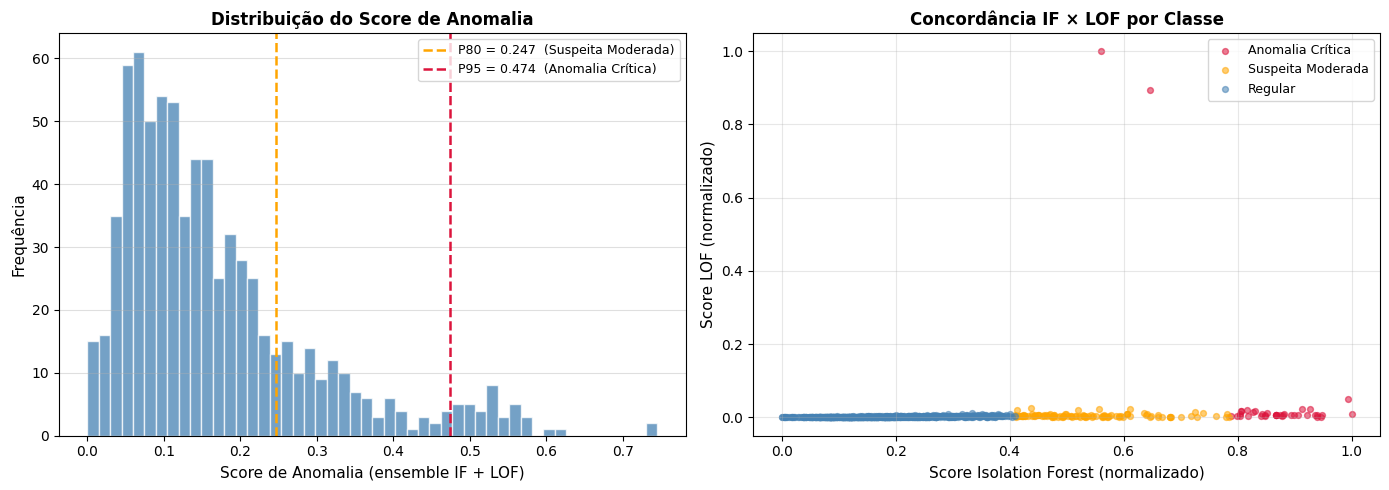

Figura salva: exports/fig_01_score_distribuicao.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Histograma do score ensemble ---
# Mostra como os scores se distribuem e onde os thresholds P80/P95 recaem.
ax1 = axes[0]
ax1.hist(score_ensemble, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
ax1.axvline(P80, color='orange', linestyle='--', lw=1.8,
            label=f'P80 = {P80:.3f}  (Suspeita Moderada)')
ax1.axvline(P95, color='crimson', linestyle='--', lw=1.8,
            label=f'P95 = {P95:.3f}  (Anomalia Crítica)')
ax1.set_xlabel('Score de Anomalia (ensemble IF + LOF)', fontsize=11)
ax1.set_ylabel('Frequência', fontsize=11)
ax1.set_title('Distribuição do Score de Anomalia', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.4)

# --- Gráfico 2: Dispersão IF × LOF ---
# Mostra a concordância entre os dois algoritmos.
# Pontos no canto superior direito (alto em ambos) são os mais robustamente anômalos.
ax2 = axes[1]
cores = {'Anomalia Crítica': 'crimson', 'Suspeita Moderada': 'orange', 'Regular': 'steelblue'}
for classe, cor in cores.items():
    mask_c = df_ti['classificacao'] == classe
    ax2.scatter(
        if_scores_norm[mask_c], lof_scores_norm[mask_c],
        c=cor, alpha=0.55, s=18, label=classe, rasterized=True
    )
ax2.set_xlabel('Score Isolation Forest (normalizado)', fontsize=11)
ax2.set_ylabel('Score LOF (normalizado)', fontsize=11)
ax2.set_title('Concordância IF × LOF por Classe', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_01_score_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: exports/fig_01_score_distribuicao.png')

### 11.2 — Importância das Features

Utilizamos **Permutation Feature Importance**: permutamos aleatoriamente os valores de
uma feature de cada vez e medimos quanto o score médio de anomalia muda.

- **Aumento grande no score** ao permutar → feature importante (o modelo depende dela)
- **Pouca mudança** → feature com menor contribuição

Esta técnica é agnóstica ao algoritmo e funciona com qualquer modelo (Breiman, 2001).

Calculando importância das features (pode demorar alguns segundos)...


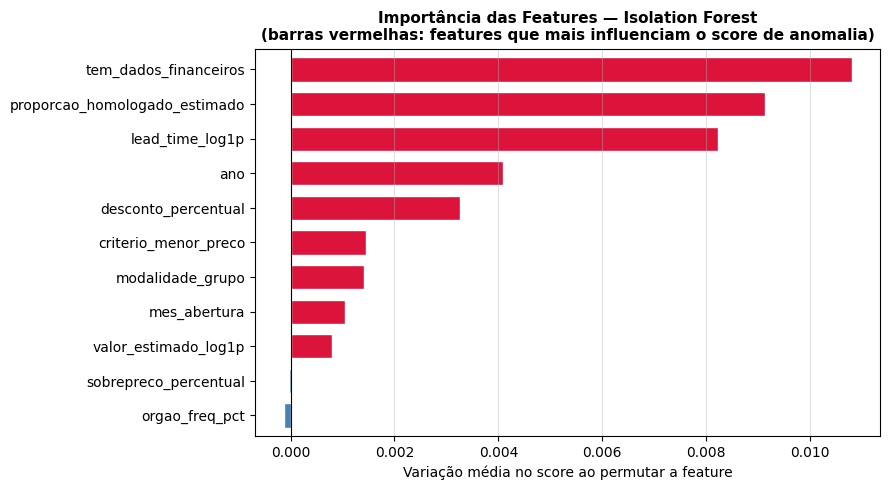

Figura salva: exports/fig_02_feature_importance.png

Feature mais importante: tem_dados_financeiros


In [14]:
def calcular_permutation_importance(model, X, feature_names, n_repeats=15, seed=42):
    """
    Calcula Permutation Feature Importance para o Isolation Forest.

    Para cada feature j:
      1. Salva o score de referência (sem permutação)
      2. Permuta os valores da feature j aleatoriamente
      3. Calcula o novo score médio
      4. A diferença (novo - referência) indica o quanto a feature contribui

    Retorna: Series com importância por feature, ordenada crescentemente
    """
    rng       = np.random.RandomState(seed)
    baseline  = -model.score_samples(X).mean()  # score médio sem permutação
    importancias = []

    for j in range(X.shape[1]):
        deltas = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            rng.shuffle(X_perm[:, j])             # embaralha a coluna j
            score_perm = -model.score_samples(X_perm).mean()
            deltas.append(score_perm - baseline)  # variação do score
        importancias.append(np.mean(deltas))       # média das n_repeats variações

    return pd.Series(importancias, index=feature_names).sort_values(ascending=True)


print('Calculando importância das features (pode demorar alguns segundos)...')
feat_imp = calcular_permutation_importance(iso_forest, X_ti, NOMES_FEATURES, n_repeats=15)

# Visualização: barras vermelhas = features que mais contribuem para o score de anomalia
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if v > 0 else 'steelblue' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white', width=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Variação média no score ao permutar a feature', fontsize=10)
ax.set_title('Importância das Features — Isolation Forest\n'
             '(barras vermelhas: features que mais influenciam o score de anomalia)',
             fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: exports/fig_02_feature_importance.png')
print(f'\nFeature mais importante: {feat_imp.idxmax()}')

### 11.3 — SHAP: Explicação Individual por Instância (se disponível)

SHAP (Lundberg & Lee, 2017) atribui a cada feature um **valor de Shapley** que quantifica
sua contribuição marginal para o score de anomalia daquela instância específica.

Ao contrário da importância global (seção anterior), o SHAP responde:
> *"Por que THIS registro específico foi marcado como anômalo?"*

Calculando SHAP values (TreeExplainer para Isolation Forest)...


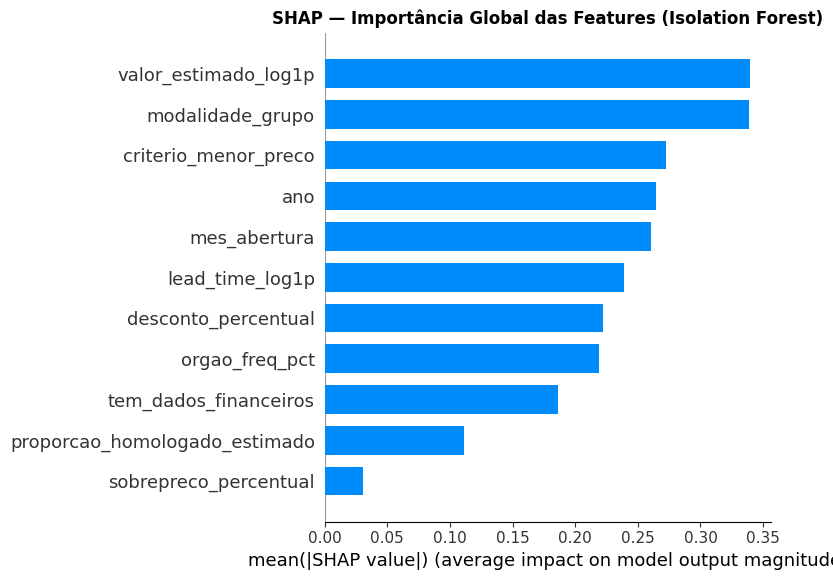


Waterfall da anomalia crítica de maior score:
  Registro: numprocesso=698  ano=2023


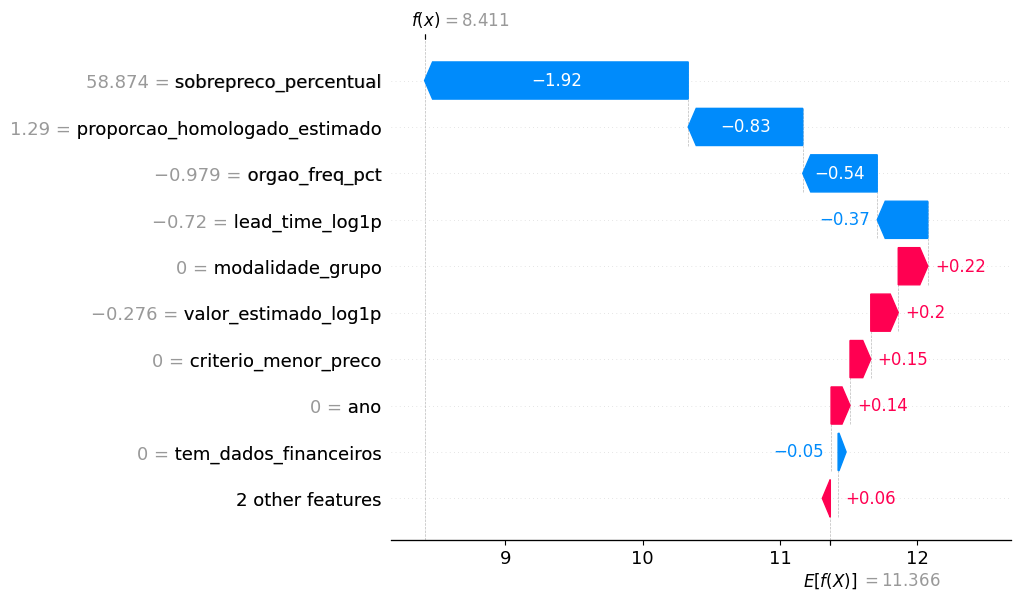

In [15]:
if SHAP_DISPONIVEL:
    print('Calculando SHAP values (TreeExplainer para Isolation Forest)...')

    # TreeExplainer é compatível com modelos baseados em árvores (IF incluído)
    explainer   = shap.TreeExplainer(iso_forest)
    shap_values = explainer.shap_values(X_ti)

    # Summary plot: visão geral de quais features mais contribuem para anomalia
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values, X_ti,
        feature_names=NOMES_FEATURES,
        show=False, plot_type='bar'
    )
    plt.title('SHAP — Importância Global das Features (Isolation Forest)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(EXPORTS_DIR / 'fig_03_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Waterfall plot: explica a anomalia crítica com maior score
    idx_criticas = np.where(df_ti['classificacao'].values == 'Anomalia Crítica')[0]
    if len(idx_criticas) > 0:
        top_idx = idx_criticas[np.argmax(score_ensemble[idx_criticas])]
        print(f'\nWaterfall da anomalia crítica de maior score:')
        print(f'  Registro: numprocesso={df_ti.iloc[top_idx]["numprocesso"]}  '
              f'ano={df_ti.iloc[top_idx]["ano"]}')
        shap.plots.waterfall(
            shap.Explanation(
                values=shap_values[top_idx],
                base_values=explainer.expected_value,
                data=X_ti[top_idx],
                feature_names=NOMES_FEATURES
            )
        )
else:
    print('SHAP não disponível. Usando análise de desvio por feature na seção 11.4.')
    print('Para ativar: pip install shap  e reinicie o kernel.')

### 11.4 — Perfil das Anomalias: Driver Principal

Para cada registro anômalo, calculamos o **z-score robusto** de cada feature em relação
ao grupo Regular. A feature com maior desvio absoluto é o "driver" da anomalia:

$$z_j = \frac{x_j - \text{mediana}_{\text{Regular}}(j)}{\text{IQR}_{\text{Regular}}(j)}$$

Isso produz uma explicação textual para cada anomalia, sem necessidade de SHAP.

Drivers principais das anomalias detectadas:
tipo_anomalia
Valor Estimado Atípico      62
Prazo Processual Atípico    35
Desconto Atípico            34
Modalidade Incomum           9
Sazonalidade Atípica         7
Sobrepreço                   3


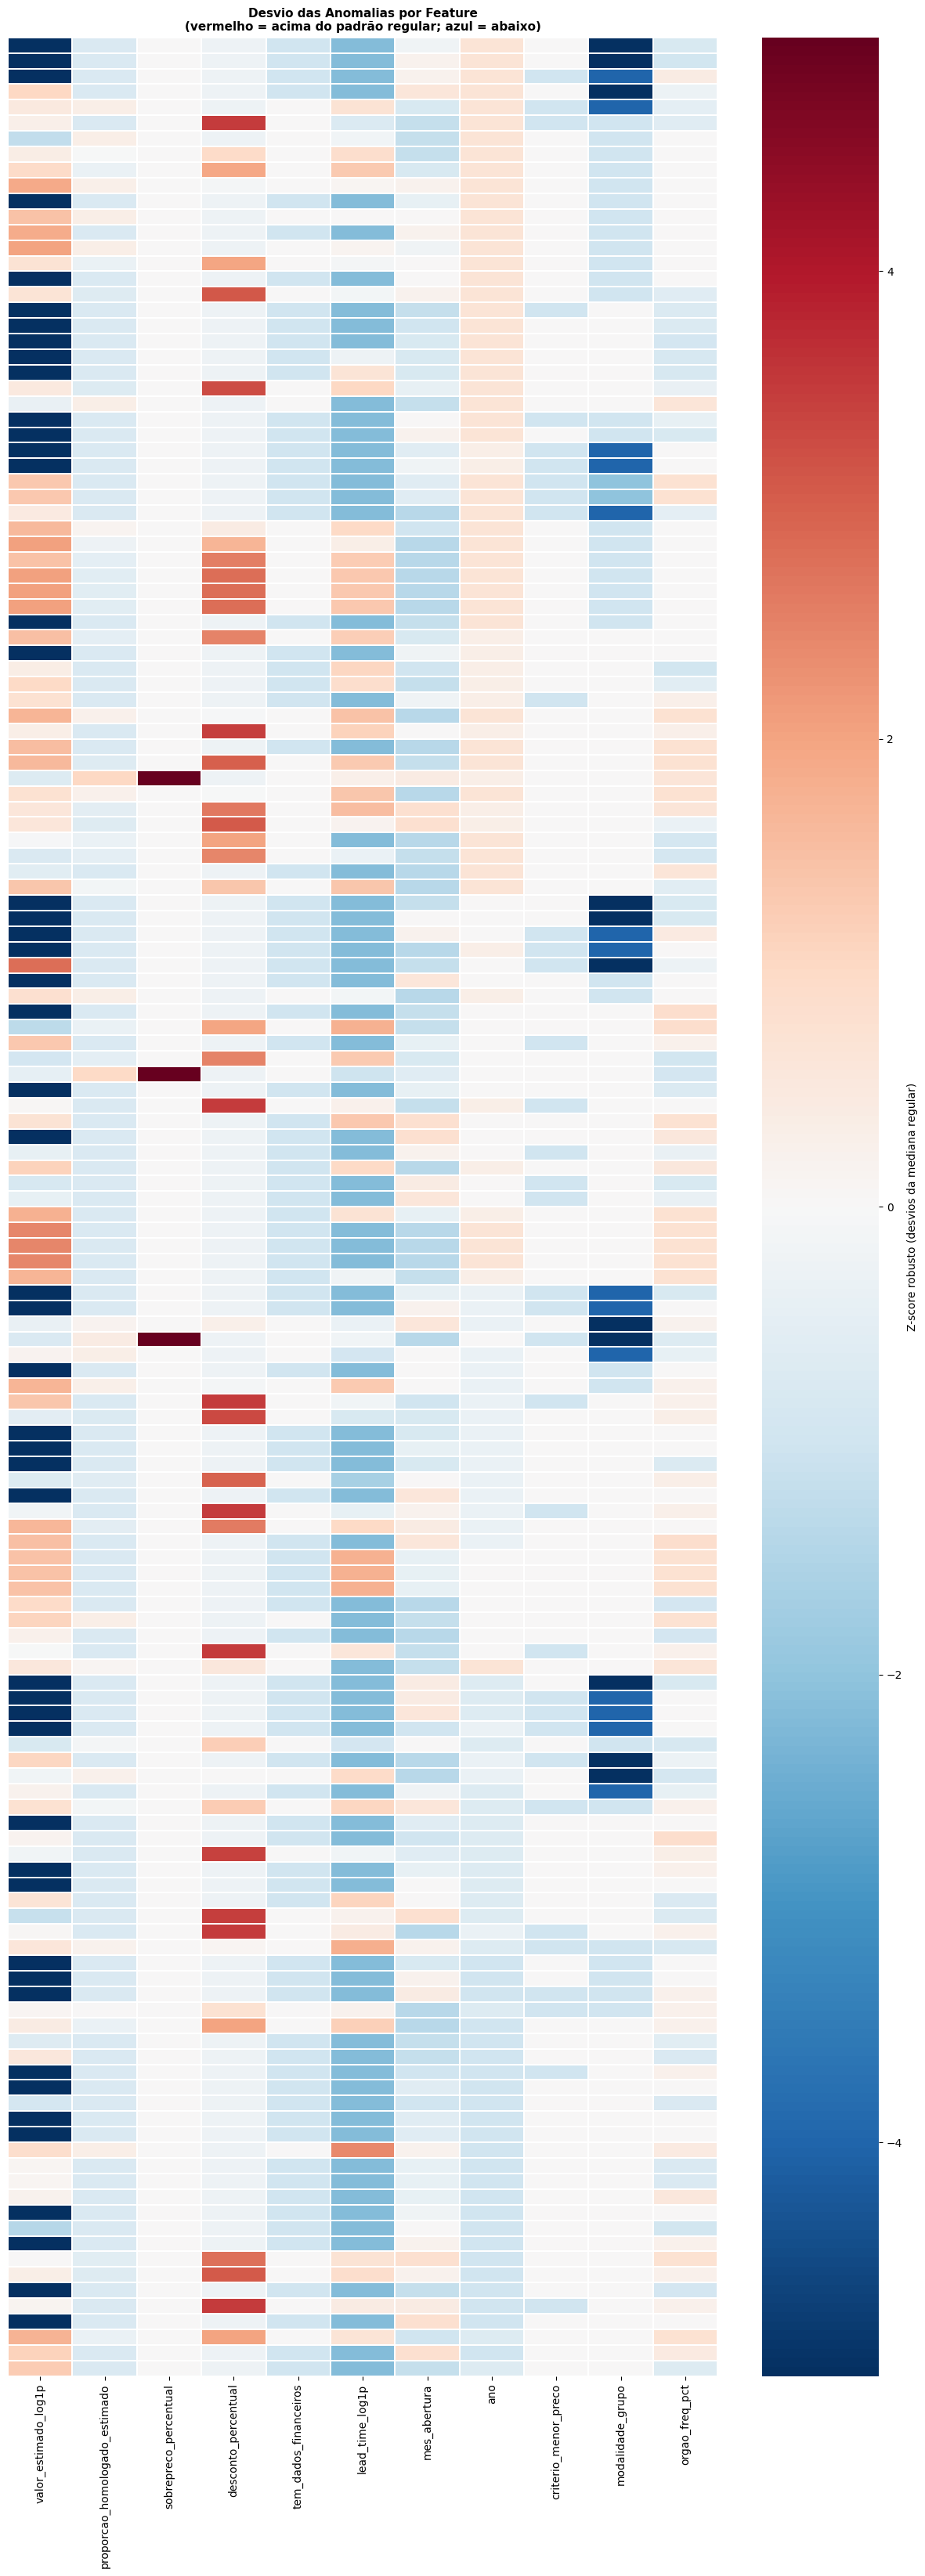

Figura salva: exports/fig_04_heatmap_zscores.png


In [16]:
# =============================================================================
# REFERÊNCIA: medianas e IQR dos registros regulares
# O "normal" é definido pelo grupo Regular — é em relação a eles que medimos o desvio.
# =============================================================================
mask_regular = df_ti['classificacao'] == 'Regular'
feat_regular = feat_ti[mask_regular]

med_ref = feat_regular.median()             # mediana de cada feature nos registros normais
iqr_ref = (
    feat_regular.quantile(0.75)
    - feat_regular.quantile(0.25)
).replace(0, 1)                             # substitui IQR=0 por 1 para evitar divisão por zero

# =============================================================================
# CÁLCULO DOS Z-SCORES PARA AS ANOMALIAS
# =============================================================================
anomalias_df  = df_ti[df_ti['flag_anomalia']].copy()
feat_anomalias = feat_ti.loc[anomalias_df.index]
z_scores = (feat_anomalias - med_ref) / iqr_ref

# Driver principal: feature com maior desvio absoluto em relação ao padrão regular
anomalias_df['driver_principal'] = z_scores.abs().idxmax(axis=1)
anomalias_df['z_score_driver']   = z_scores.abs().max(axis=1).round(2)

# Mapeamento para rótulos descritivos (mais legíveis para o orientador e banca)
LABELS_DRIVER = {
    'sobrepreco_percentual':          'Sobrepreço',
    'proporcao_homologado_estimado':  'Relação Valor Anômala',
    'valor_estimado_log1p':           'Valor Estimado Atípico',
    'lead_time_log1p':                'Prazo Processual Atípico',
    'desconto_percentual':            'Desconto Atípico',
    'criterio_menor_preco':           'Critério de Julgamento Incomum',
    'modalidade_grupo':               'Modalidade Incomum',
    'orgao_freq_pct':                 'Órgão com Padrão Atípico',
    'mes_abertura':                   'Sazonalidade Atípica',
    'ano':                            'Padrão Temporal',
    'tem_dados_financeiros':          'Ausência de Dados Financeiros',
}
anomalias_df['tipo_anomalia'] = anomalias_df['driver_principal'].map(LABELS_DRIVER).fillna('Outro')

# Resultado
print('Drivers principais das anomalias detectadas:')
print(anomalias_df['tipo_anomalia'].value_counts().to_string())

# =============================================================================
# HEATMAP DOS Z-SCORES
# Visualiza o padrão de desvio de cada anomalia por feature.
# Vermelho = valor muito acima do normal; Azul = muito abaixo.
# =============================================================================
fig, ax = plt.subplots(figsize=(12, max(4, len(anomalias_df) * 0.22)))
sns.heatmap(
    z_scores.clip(-5, 5),      # limita a ±5 desvios para melhor contraste visual
    cmap='RdBu_r', center=0, vmin=-5, vmax=5,
    ax=ax,
    cbar_kws={'label': 'Z-score robusto (desvios da mediana regular)'},
    yticklabels=False,         # oculta rótulos das linhas se houver muitas anomalias
    linewidths=0.05
)
ax.set_title(
    'Desvio das Anomalias por Feature\n'
    '(vermelho = acima do padrão regular; azul = abaixo)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_04_heatmap_zscores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva: exports/fig_04_heatmap_zscores.png')

### 11.5 — Distribuição por Tipo de Anomalia

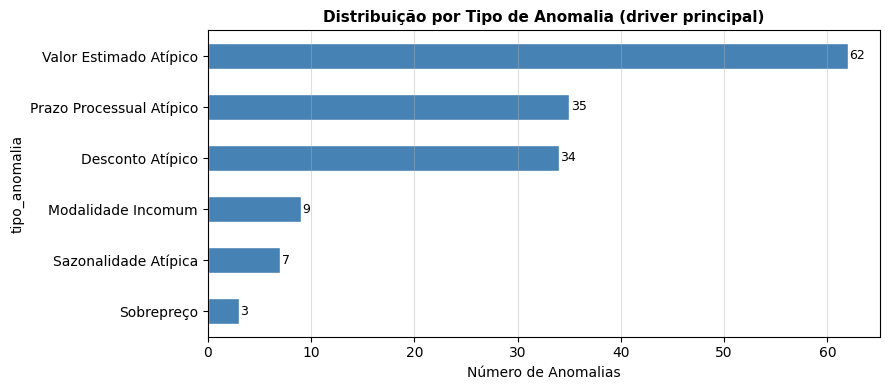

Resumo por tipo de anomalia:


,Quantidade,Score_Medio,Valor_Estim_Medio
tipo_anomalia,,,
Valor Estimado Atípico,62,0.40,"10,994,532,363.73"
Prazo Processual Atípico,35,0.31,"1,379,859,514.29"
Desconto Atípico,34,0.37,"2,868,717,897.68"
Modalidade Incomum,9,0.41,"19,384,606,699.89"
Sazonalidade Atípica,7,0.31,"933,255,057.57"
Sobrepreço,3,0.70,"8,740,826.33"


In [17]:
tipo_dist = anomalias_df['tipo_anomalia'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
tipo_dist.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Número de Anomalias', fontsize=10)
ax.set_title('Distribuição por Tipo de Anomalia (driver principal)', fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
# Rótulos com contagem ao lado de cada barra
for i, v in enumerate(tipo_dist.sort_values().values):
    ax.text(v + 0.15, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_05_tipo_anomalia.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela resumo: quantidade, score médio e valor estimado médio por tipo
resumo_tipo = anomalias_df.groupby('tipo_anomalia').agg(
    Quantidade         = ('tipo_anomalia',    'count'),
    Score_Medio        = ('score_anomalia',   'mean'),
    Valor_Estim_Medio  = ('valor_estimado',   'mean'),
).sort_values('Quantidade', ascending=False).round(4)

print('Resumo por tipo de anomalia:')
display(resumo_tipo)

### 11.6 — Top Anomalias Críticas

In [18]:
# Colunas a exibir — filtramos apenas as que existem no DataFrame
cols = [
    'numprocesso', 'ano', 'modalidade', 'orgao',
    'valor_estimado', 'valor_ou_desconto_homologado',
    'lead_time_dias', 'classificacao', 'score_anomalia', 'tipo_anomalia'
]
cols = [c for c in cols if c in anomalias_df.columns]

# Top 20 anomalias críticas ordenadas por score
criticas = (
    anomalias_df[anomalias_df['classificacao'] == 'Anomalia Crítica']
    .sort_values('score_anomalia', ascending=False)
    .head(20)
)
print('=' * 100)
print('TOP ANOMALIAS CRÍTICAS (ordenadas por score)')
print('=' * 100)
display(criticas[cols])

# Top 10 suspeitas moderadas
suspeitas = (
    anomalias_df[anomalias_df['classificacao'] == 'Suspeita Moderada']
    .sort_values('score_anomalia', ascending=False)
    .head(10)
)
print('\n' + '=' * 100)
print('TOP 10 SUSPEITAS MODERADAS')
print('=' * 100)
display(suspeitas[cols])

TOP ANOMALIAS CRÍTICAS (ordenadas por score)


,numprocesso,ano,modalidade,orgao,valor_estimado,valor_ou_desconto_homologado,lead_time_dias,classificacao,score_anomalia,tipo_anomalia
5346,698,2023,Pregão Eletrônico,EPR-Serviço Social Autônomo E-PARANA COMUNICACAO,"13,829,739.00","21,971,900.00",4.00,Anomalia Crítica,0.75,Sobrepreço
3327,1148,2024,Pregão Eletrônico (Lei Federal 14.133/2021),UEL-Universidade Estadual de Londrina,"6,842,740.00","11,320,000.00",32.00,Anomalia Crítica,0.74,Sobrepreço
7303,212,2022,Concorrência Pública,UNIOESTE CASC-Universidade Estadual do Oeste do Paraná - Campus Cascavel,"5,550,000.00","5,900,000.00",16.00,Anomalia Crítica,0.62,Sobrepreço
224,1,2025,Licitação Eletrônica - Estatal,COHAPAR-Companhia de Habitação do Paraná,"113,220,000.00",451.00,7.00,Anomalia Crítica,0.60,Desconto Atípico
9821,2,2021,Chamamento Público,CELEPAR-Companhia de Tecnologia da Informação e Comunicação do Paraná,0.00,NaN,0.00,Anomalia Crítica,0.57,Valor Estimado Atípico
11972,8,2020,Licitação Presencial - Estatal,APPA-Administração dos Portos de Paranaguá e Antonina,NaN,NaN,0.00,Anomalia Crítica,0.57,Valor Estimado Atípico
9820,1,2021,Chamamento Público,CELEPAR-Companhia de Tecnologia da Informação e Comunicação do Paraná,0.00,NaN,0.00,Anomalia Crítica,0.57,Valor Estimado Atípico
4535,4,2023,Concorrência Pública,IAT-Instituto Água e Terra (Antigo IAP),"171,675,512,640.00",NaN,0.00,Anomalia Crítica,0.56,Modalidade Incomum
4412,29,2023,Chamamento Público,CELEPAR-Companhia de Tecnologia da Informação e Comunicação do Paraná,NaN,NaN,0.00,Anomalia Crítica,0.56,Valor Estimado Atípico
12070,78,2020,Pregão Eletrônico,APPA-Administração dos Portos de Paranaguá e Antonina,NaN,NaN,0.00,Anomalia Crítica,0.56,Valor Estimado Atípico



TOP 10 SUSPEITAS MODERADAS


,numprocesso,ano,modalidade,orgao,valor_estimado,valor_ou_desconto_homologado,lead_time_dias,classificacao,score_anomalia,tipo_anomalia
4386,10,2023,Audiência Pública,SEAP-Secretaria de Estado da Administração e da Previdência,0.00,NaN,0.00,Suspeita Moderada,0.47,Valor Estimado Atípico
12868,928,2020,Pregão Eletrônico,EPR-Serviço Social Autônomo E-PARANA COMUNICACAO,NaN,NaN,0.00,Suspeita Moderada,0.47,Valor Estimado Atípico
11959,1,2020,Licitação Eletrônica - Estatal,CELEPAR-Companhia de Tecnologia da Informação e Comunicação do Paraná,NaN,NaN,0.00,Suspeita Moderada,0.47,Valor Estimado Atípico
2150,102,2024,Licitação Eletrônica - Estatal,CELEPAR-Companhia de Tecnologia da Informação e Comunicação do Paraná,"3,837,033,742.00","941,740,000.00",133.00,Suspeita Moderada,0.46,Desconto Atípico
10018,13,2021,Licitação Presencial - Estatal,APPA-Administração dos Portos de Paranaguá e Antonina,"457,772,691.00","270,000,000.00",99.00,Suspeita Moderada,0.45,Desconto Atípico
11981,17,2020,Licitação Presencial - Estatal,APPA-Administração dos Portos de Paranaguá e Antonina,"66,050,291.00","48,175,680.00",29.00,Suspeita Moderada,0.44,Sazonalidade Atípica
11963,7,2020,Licitação Eletrônica - Estatal,CELEPAR-Companhia de Tecnologia da Informação e Comunicação do Paraná,NaN,NaN,0.00,Suspeita Moderada,0.44,Valor Estimado Atípico
3317,1138,2024,Pregão Eletrônico (Lei Federal 14.133/2021),DECON-Departamento de Logística para Contratações Públicas (Antigo DEAM),"5,476,672,348.00","703,711,283.00",140.00,Suspeita Moderada,0.43,Desconto Atípico
13132,1207,2020,Pregão Eletrônico,CELEPAR-Companhia de Tecnologia da Informação e Comunicação do Paraná,NaN,NaN,0.00,Suspeita Moderada,0.42,Valor Estimado Atípico
2160,110,2024,Licitação Eletrônica - Estatal,CELEPAR-Companhia de Tecnologia da Informação e Comunicação do Paraná,NaN,NaN,0.00,Suspeita Moderada,0.41,Valor Estimado Atípico


### 11.7 — Análise por Órgão

Identifica os órgãos com maior concentração de licitações de TI anômalas.
Apenas órgãos com pelo menos 5 licitações de TI são incluídos (mínimo estatístico).

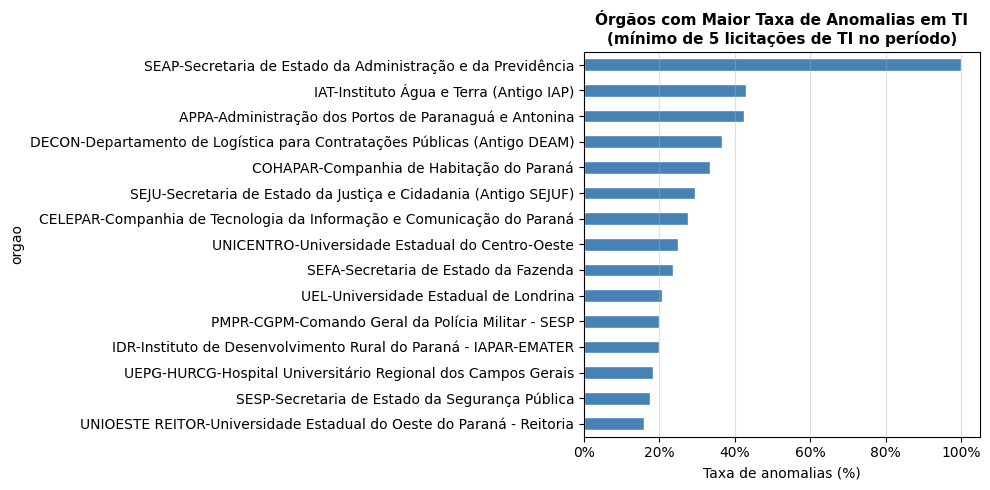

Top 15 órgãos por taxa de anomalia em TI:


,total,anomalias,score_medio,taxa_anomalia_pct
orgao,,,,
SEAP-Secretaria de Estado da Administração e da Previdência,6,6,0.48,100.00
IAT-Instituto Água e Terra (Antigo IAP),7,3,0.25,42.90
APPA-Administração dos Portos de Paranaguá e Antonina,33,14,0.25,42.40
DECON-Departamento de Logística para Contratações Públicas (Antigo DEAM),49,18,0.24,36.70
COHAPAR-Companhia de Habitação do Paraná,6,2,0.30,33.30
SEJU-Secretaria de Estado da Justiça e Cidadania (Antigo SEJUF),17,5,0.18,29.40
CELEPAR-Companhia de Tecnologia da Informação e Comunicação do Paraná,156,43,0.17,27.60
UNICENTRO-Universidade Estadual do Centro-Oeste,8,2,0.11,25.00
SEFA-Secretaria de Estado da Fazenda,17,4,0.19,23.50


In [19]:
# Estatísticas por órgão: total, anomalias e taxa
orgao_stats = df_ti.groupby('orgao').agg(
    total     = ('flag_anomalia', 'count'),
    anomalias = ('flag_anomalia', 'sum'),
    score_medio = ('score_anomalia', 'mean')
)
orgao_stats['taxa_anomalia_pct'] = (
    orgao_stats['anomalias'] / orgao_stats['total'] * 100
).round(1)

# Filtra órgãos com dados suficientes para análise
orgao_stats = orgao_stats[orgao_stats['total'] >= 5]

top_orgaos = orgao_stats.sort_values('taxa_anomalia_pct', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_orgaos['taxa_anomalia_pct'].sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Taxa de anomalias (%)', fontsize=10)
ax.set_title(
    'Órgãos com Maior Taxa de Anomalias em TI\n'
    '(mínimo de 5 licitações de TI no período)',
    fontsize=11, fontweight='bold'
)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_06_anomalias_por_orgao.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 órgãos por taxa de anomalia em TI:')
display(top_orgaos)

---
## 12 — Exportação dos Resultados

In [20]:
# =============================================================================
# ADICIONA COLUNAS DE INTERPRETAÇÃO AO DATASET COMPLETO DE TI
# Mescla o driver_principal e tipo_anomalia calculados para as anomalias
# de volta ao dataset completo de TI (registros regulares recebem NaN nessas colunas).
# =============================================================================
df_ti_export = df_ti.sort_values('score_anomalia', ascending=False).copy()

df_ti_export = df_ti_export.merge(
    anomalias_df[['driver_principal', 'tipo_anomalia', 'z_score_driver']],
    left_index=True, right_index=True, how='left'
)

# =============================================================================
# ARQUIVO 1: Dataset TI completo com scores e classificações
# Útil para explorar todos os registros e entender a distribuição dos scores.
# =============================================================================
path_completo  = EXPORTS_DIR / '5_licitacoes_ti_com_score_ml.csv'
df_ti_export.to_csv(path_completo, sep=';', index=False)

# =============================================================================
# ARQUIVO 2: Apenas as anomalias (Críticas + Suspeitas)
# Arquivo focado para revisão manual por auditores.
# =============================================================================
path_anomalias = EXPORTS_DIR / '6_licitacoes_ti_anomalias_ml.csv'
anomalias_df.sort_values('score_anomalia', ascending=False).to_csv(
    path_anomalias, sep=';', index=False
)

print('✓ Arquivos exportados:')
print(f'  {path_completo.name}:  {len(df_ti_export):,} registros')
print(f'  {path_anomalias.name}: {len(anomalias_df):,} registros')
print()
display({
    'TI completo (com scores)': FileLink(path_completo),
    'Somente anomalias':        FileLink(path_anomalias)
})

✓ Arquivos exportados:
  5_licitacoes_ti_com_score_ml.csv:  748 registros
  6_licitacoes_ti_anomalias_ml.csv: 150 registros



{'TI completo (com scores)': /Users/azevedo/GitHub/anomalyClassifier/exports/5_licitacoes_ti_com_score_ml.csv,
 'Somente anomalias': /Users/azevedo/GitHub/anomalyClassifier/exports/6_licitacoes_ti_anomalias_ml.csv}

---
## 13 — Sumário Final e Limitações

In [21]:
n_criticas  = (df_ti['classificacao'] == 'Anomalia Crítica').sum()
n_suspeitas = (df_ti['classificacao'] == 'Suspeita Moderada').sum()
n_regular   = (df_ti['classificacao'] == 'Regular').sum()
n_total     = len(df_ti)

ano_min = clean_df['dataabertura'].min().year
ano_max = clean_df['dataabertura'].max().year

print('=' * 72)
print(' SUMÁRIO — DETECÇÃO DE ANOMALIAS EM LICITAÇÕES DE TI')
print('=' * 72)
print(f'  Período analisado          : {ano_min} – {ano_max}')
print(f'  Total de registros (geral) : {len(clean_df):,}')
print(f'  Registros de TI            : {n_total:,}')
print(f'  Anomalias Críticas         : {n_criticas:,}  ({n_criticas/n_total*100:.1f}%)')
print(f'  Suspeitas Moderadas        : {n_suspeitas:,}  ({n_suspeitas/n_total*100:.1f}%)')
print(f'  Regulares                  : {n_regular:,}  ({n_regular/n_total*100:.1f}%)')
print()
print(' METODOLOGIA')
print(f'  Algoritmos    : Isolation Forest (Liu et al., 2008)')
print(f'                  + Local Outlier Factor (Breunig et al., 2000)')
print(f'  Ensemble      : {PESO_IF:.0%} IF + {PESO_LOF:.0%} LOF')
print(f'  Threshold P95 : score ≥ {P95:.4f} → Anomalia Crítica')
print(f'  Threshold P80 : score ≥ {P80:.4f} → Suspeita Moderada')
print(f'  Features ({len(NOMES_FEATURES)})  : {NOMES_FEATURES}')
print()
print(' LIMITAÇÕES')
print('  1. SEM RÓTULOS: impossível calcular precisão/recall sem ground truth.')
print('     → Os resultados indicam DESVIO ESTATÍSTICO, não confirmação de fraude.')
print('     → Registros anômalos requerem revisão manual por auditores competentes.')
print()
print('  2. COMPLETUDE FINANCEIRA: registros sem valor_estimado têm features parciais.')
print('     → A feature tem_dados_financeiros explicita isso ao modelo.')
print()
print('  3. FILTRO DE TI: keywords podem capturar falsos positivos ou perder registros.')
print('     → Recomenda-se revisão periódica da lista de palavras-chave.')
print()
print('  4. ESCOPO: dados de licitações do Estado do Paraná (2020–2025).')
print('     → A generalização para outros estados requer revalidação do modelo.')
print('=' * 72)

 SUMÁRIO — DETECÇÃO DE ANOMALIAS EM LICITAÇÕES DE TI
  Período analisado          : 2018 – 2099
  Total de registros (geral) : 13,536
  Registros de TI            : 748
  Anomalias Críticas         : 38  (5.1%)
  Suspeitas Moderadas        : 112  (15.0%)
  Regulares                  : 598  (79.9%)

 METODOLOGIA
  Algoritmos    : Isolation Forest (Liu et al., 2008)
                  + Local Outlier Factor (Breunig et al., 2000)
  Ensemble      : 60% IF + 40% LOF
  Threshold P95 : score ≥ 0.4740 → Anomalia Crítica
  Threshold P80 : score ≥ 0.2472 → Suspeita Moderada
  Features (11)  : ['valor_estimado_log1p', 'proporcao_homologado_estimado', 'sobrepreco_percentual', 'desconto_percentual', 'tem_dados_financeiros', 'lead_time_log1p', 'mes_abertura', 'ano', 'criterio_menor_preco', 'modalidade_grupo', 'orgao_freq_pct']

 LIMITAÇÕES
  1. SEM RÓTULOS: impossível calcular precisão/recall sem ground truth.
     → Os resultados indicam DESVIO ESTATÍSTICO, não confirmação de fraude.
     → Registr